<a href="https://colab.research.google.com/github/aggelikntaliani-lgtm/scRNA-seq-Rstudio/blob/main/scRNAseq_python_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 118.7 MB/s eta 0:00:00


In [7]:
import scanpy as sc

In [11]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM5226nnn/GSM5226574/suppl/GSM5226574_C51ctr_raw_counts.csv.gz
adata = sc.read_csv('GSM5226574_C51ctr_raw_counts.csv.gz').T
adata

--2026-03-08 08:15:52--  https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM5226nnn/GSM5226574/suppl/GSM5226574_C51ctr_raw_counts.csv.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9077491 (8.7M) [application/x-gzip]
Saving to: ‘GSM5226574_C51ctr_raw_counts.csv.gz’

GSM5226574_C51ctr_r 100%[===================>]   8.66M  10.8MB/s    in 0.8s    

2026-03-08 08:15:53 (10.8 MB/s) - ‘GSM5226574_C51ctr_raw_counts.csv.gz’ saved [9077491/9077491]



AnnData object with n_obs × n_vars = 6099 × 34546

In [12]:
adata.X.shape

(6099, 34546)

In [13]:
!pip install scvi-tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 58.8 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=5472d13e103b1ec078af533a60404efc875ee12b35ee5398ea7b2475e50c6d7f
  Stor

In [14]:
import scvi

In [16]:
adata

AnnData object with n_obs × n_vars = 6099 × 34546

In [17]:
sc.pp.filter_genes(adata, min_cells = 10)

In [18]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, flavor = 'seurat_v3')

In [19]:
scvi.model.SCVI.setup_anndata(adata)
vae = scvi.model.SCVI(adata)
vae.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


In [20]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

INFO     Creating doublets, preparing SOLO model.                                                                  


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric validation_loss did not improve in the last 30 records. Best score: 0.278. Signaling Trainer to stop.


In [21]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)
df

/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py:124: UserWarning: Prior to scvi-tools 1.1.3, `SOLO.predict` with `soft=True` (the default option) returned logits instead of probabilities. This behavior has since been corrected to return probabilities. The previous behavior can be replicated by passing in `return_logits=True`.
  return func(*args, **kwargs)


,doublet,singlet,prediction
TAGGTACCATGGCCAC-1_1,0.820749,0.179251,doublet
ATTCACTGTAACAGGC-1_1,0.833465,0.166535,doublet
TAACTTCCAACCACGC-1_1,0.061198,0.938802,singlet
TTGGGTACACGACAAG-1_1,0.871822,0.128178,doublet
AGGCCACAGAGTCACG-1_1,0.765412,0.234588,doublet
...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.039008,0.960992,singlet
CACTGGGGTCTACGTA-1_1,0.002783,0.997217,singlet
CATACTTGTAGAGGAA-1_1,0.010115,0.989885,singlet
TTTGGTTTCCACGGAC-1_1,0.003434,0.996566,singlet


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
df.groupby('prediction').count()

,doublet,singlet
prediction,,
doublet,1125,1125
singlet,4974,4974


In [24]:
df['dif'] = df.doublet - df.singlet
df

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.820749,0.179251,doublet,0.641499
ATTCACTGTAACAGGC-1_1,0.833465,0.166535,doublet,0.666930
TAACTTCCAACCACGC-1_1,0.061198,0.938802,singlet,-0.877604
TTGGGTACACGACAAG-1_1,0.871822,0.128178,doublet,0.743644
AGGCCACAGAGTCACG-1_1,0.765412,0.234588,doublet,0.530824
...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,0.039008,0.960992,singlet,-0.921984
CACTGGGGTCTACGTA-1_1,0.002783,0.997217,singlet,-0.994435
CATACTTGTAGAGGAA-1_1,0.010115,0.989885,singlet,-0.979771
TTTGGTTTCCACGGAC-1_1,0.003434,0.996566,singlet,-0.993131


In [25]:
import seaborn as sns

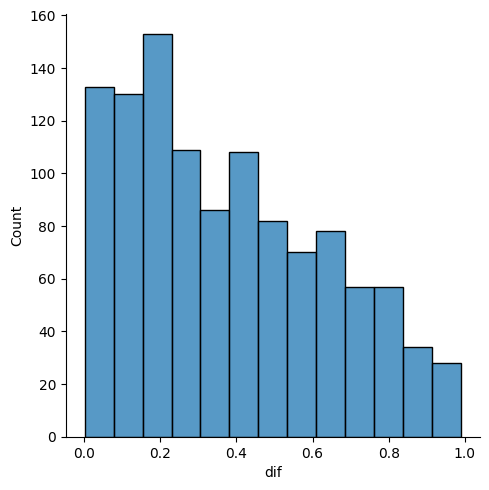

In [26]:
sns.displot(df[df.prediction == 'doublet'], x = 'dif')

In [27]:
doublets = df[(df.prediction == 'doublet') & (df.dif > 0.4)]
doublets

,doublet,singlet,prediction,dif
TAGGTACCATGGCCAC-1_1,0.820749,0.179251,doublet,0.641499
ATTCACTGTAACAGGC-1_1,0.833465,0.166535,doublet,0.666930
TTGGGTACACGACAAG-1_1,0.871822,0.128178,doublet,0.743644
AGGCCACAGAGTCACG-1_1,0.765412,0.234588,doublet,0.530824
CACTGAAGTCGAAGCA-1_1,0.948694,0.051306,doublet,0.897388
...,...,...,...,...
CAATACGCAATGTGGG-1_1,0.708158,0.291842,doublet,0.416316
AAAGAACGTACACTCA-1_1,0.717520,0.282480,doublet,0.435039
AACCCAATCTCGACCT-1_1,0.943952,0.056048,doublet,0.887904
AACAGGGAGGTCCAGA-1_1,0.771863,0.228137,doublet,0.543726


In [28]:
adata = sc.read_csv('GSM5226574_C51ctr_raw_counts.csv.gz').T

In [29]:
adata.obs['doublet'] = adata.obs.index.isin(doublets.index)

In [30]:
adata.obs

,doublet
TAGGTACCATGGCCAC-1_1,True
ATTCACTGTAACAGGC-1_1,True
TAACTTCCAACCACGC-1_1,False
TTGGGTACACGACAAG-1_1,True
AGGCCACAGAGTCACG-1_1,True
...,...
CGCCATTGTTTGCCGG-1_1,False
CACTGGGGTCTACGTA-1_1,False
CATACTTGTAGAGGAA-1_1,False
TTTGGTTTCCACGGAC-1_1,False


In [31]:
adata = adata[~adata.obs.doublet]

In [32]:
adata

View of AnnData object with n_obs × n_vars = 5608 × 34546
    obs: 'doublet'

In [33]:
adata.var['mt'] = adata.var.index.str.startswith('MT-')

/tmp/ipykernel_174/310233584.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var.index.str.startswith('MT-')


In [34]:
adata.var

,mt
AL627309.1,False
AL627309.5,False
AL627309.4,False
AL669831.2,False
LINC01409,False
...,...
VN1R2,False
AL031676.1,False
SMIM34A,False
AL050402.1,False


In [35]:
import pandas as pd

In [36]:
ribo_url = "http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp?geneSetName=KEGG_RIBOSOME&fileType=txt"

In [39]:
ribo_genes = pd.read_table(ribo_url, skiprows=2, header = None)
ribo_genes

,0
0,FAU
1,MRPL13
2,RPL10
3,RPL10A
4,RPL10L
...,...
83,RPS9
84,RPSA
85,RSL24D1
86,RSL24D1P11


In [42]:
adata.var['ribo'] = adata.var_names.isin(ribo_genes[0].values)

In [43]:
adata.var

,mt,ribo
AL627309.1,False,False
AL627309.5,False,False
AL627309.4,False,False
AL669831.2,False,False
LINC01409,False,False
...,...,...
VN1R2,False,False
AL031676.1,False,False
SMIM34A,False,False
AL050402.1,False,False


In [47]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo
TAACTTCCAACCACGC-1_1,False,5158,15645.0,221.0,1.412592,211.0,1.348674
TTACCGCCACTCAGAT-1_1,False,4144,11369.0,39.0,0.343038,5.0,0.043979
TTGGTTTTCCTAGCTC-1_1,False,3902,11472.0,463.0,4.035913,13.0,0.113319
CGCATAACATGCCGGT-1_1,False,3745,8617.0,119.0,1.380991,25.0,0.290124
ATCCACCAGAGGTATT-1_1,False,3913,8286.0,191.0,2.305093,34.0,0.410331
...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,355,410.0,3.0,0.731707,0.0,0.000000
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000
CATACTTGTAGAGGAA-1_1,False,360,410.0,2.0,0.487805,0.0,0.000000
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827


In [45]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top= None, log1p= False, inplace=True)

In [50]:
adata.var.sort_values('n_cells_by_counts')

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
UFSP1,False,False,3,0.000535,99.946505,3.0,3
MUC17,False,False,3,0.000535,99.946505,3.0,3
LINC01989,False,False,3,0.000535,99.946505,3.0,3
AC022903.2,False,False,3,0.000713,99.946505,4.0,3
AL359764.2,False,False,3,0.000535,99.946505,3.0,3
...,...,...,...,...,...,...,...
AKAP13,False,False,4010,2.820970,28.495007,15820.0,4010
MBNL1,False,False,4100,2.638909,26.890157,14799.0,4100
NEAT1,False,False,4104,4.950428,26.818830,27762.0,4104
ZBTB20,False,False,4246,2.397825,24.286733,13447.0,4246


In [49]:
sc.pp.filter_genes(adata, min_cells = 3)

In [54]:
adata.obs.sort_values('total_counts')

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes
TGGTACAGTTGGTGTT-1_1,False,323,401.0,0.0,0.000000,0.0,0.000000,323
CTCAACCGTTTGGGAG-1_1,False,325,401.0,0.0,0.000000,0.0,0.000000,325
CGAGAAGGTGAACTAA-1_1,False,308,401.0,0.0,0.000000,0.0,0.000000,307
CAGGGCTTCATGCGGC-1_1,False,330,401.0,7.0,1.745636,1.0,0.249377,330
AGGCATTCATCCGTTC-1_1,False,290,401.0,1.0,0.249377,0.0,0.000000,290
...,...,...,...,...,...,...,...,...
ATCCACCAGAGGTATT-1_1,False,3913,8286.0,191.0,2.305093,34.0,0.410331,3913
CGCATAACATGCCGGT-1_1,False,3745,8617.0,119.0,1.380991,25.0,0.290124,3730
TTACCGCCACTCAGAT-1_1,False,4144,11369.0,39.0,0.343038,5.0,0.043979,4140
TTGGTTTTCCTAGCTC-1_1,False,3902,11472.0,463.0,4.035913,13.0,0.113319,3897


In [52]:
#sc.pp.filter_cells(adata, min_genes = 200)

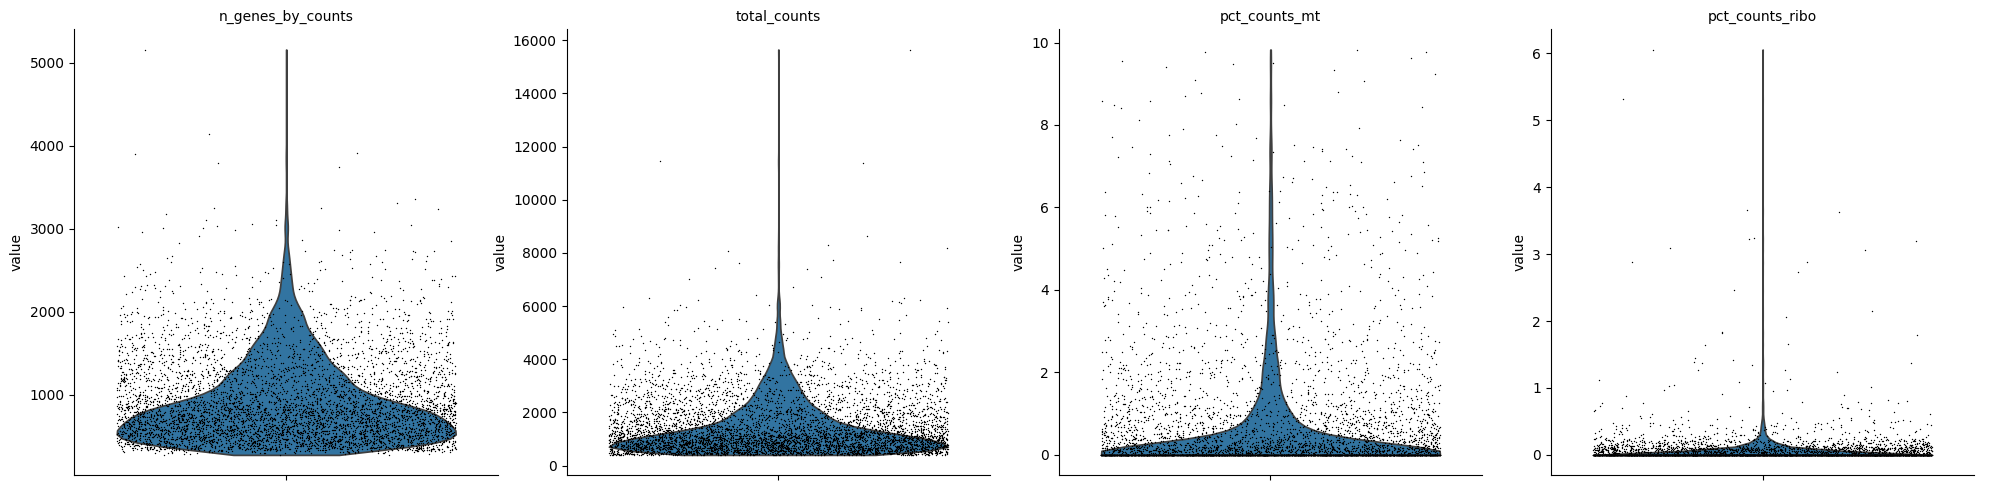

In [55]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter = 0.4, multi_panel = True)

In [56]:
import numpy as np

In [58]:
upper_lim = np.quantile(adata.obs.n_genes_by_counts.values, .98)
#Upper_lim = 3000

In [59]:
upper_lim

np.float64(2256.0)

In [60]:
adata = adata[adata.obs.n_genes_by_counts < upper_lim]

In [61]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes
ATACTTCCAAGGTCTT-1_1,False,2122,5252.0,1.0,0.019040,4.0,0.076161,2120
AGACACTTCATACAGC-1_1,False,2223,4943.0,2.0,0.040461,0.0,0.000000,2222
TCATGCCGTCTTTCAT-1_1,False,2234,4993.0,0.0,0.000000,3.0,0.060084,2228
GATAGCTCAGGCTTGC-1_1,False,2167,4879.0,0.0,0.000000,0.0,0.000000,2165
TACATTCGTACGTACT-1_1,False,2253,4776.0,13.0,0.272194,1.0,0.020938,2248
...,...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,355,410.0,3.0,0.731707,0.0,0.000000,355
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000,346
CATACTTGTAGAGGAA-1_1,False,360,410.0,2.0,0.487805,0.0,0.000000,360
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827,299


In [63]:
adata = adata[adata.obs.pct_counts_mt < 20]

In [64]:
adata = adata[adata.obs.pct_counts_ribo < 2]

In [65]:
adata

View of AnnData object with n_obs × n_vars = 5479 × 24074
    obs: 'doublet', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'

In [ ]:
#normalization

In [67]:
adata.X.sum(axis=1)

array([5250., 4941., 4987., ...,  410.,  405.,  410.], dtype=float32)

In [73]:
sc.pp.normalize_total(adata, target_sum=1e4) #normalize every cell to 10000 UMI

In [74]:
adata.X.sum(axis=1)

array([10000.   , 10000.   , 10000.002, ..., 10000.   , 10000.   ,
       10000.   ], dtype=float32)

In [75]:
sc.pp.log1p(adata)  #change to log counts

In [76]:
adata.X.sum(axis=1)

array([2858.1602, 3229.8745, 3190.5518, ..., 1191.2706, 1022.7511,
       1162.8785], dtype=float32)

In [77]:
adata.raw = adata

In [ ]:
#clustering

In [78]:
sc.pp.highly_variable_genes(adata, n_top_genes= 2000)

In [79]:
adata.var

,mt,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,highly_variable,means,dispersions,dispersions_norm
AL627309.1,False,False,6,0.001070,99.893010,6.0,6,True,0.011159,2.764080,1.243360
AL627309.5,False,False,24,0.004280,99.572040,24.0,24,False,0.027809,2.340712,-0.054340
AL627309.4,False,False,4,0.000713,99.928673,4.0,4,False,0.002535,1.702824,-2.009585
LINC01409,False,False,220,0.042083,96.077033,236.0,220,False,0.260372,2.350088,-0.025601
FAM87B,False,False,6,0.001070,99.893010,6.0,6,False,0.007268,1.947618,-1.259247
...,...,...,...,...,...,...,...,...,...,...,...
AL354822.1,False,False,115,0.020863,97.949358,117.0,115,False,0.153308,2.427188,0.210723
AL592183.1,False,False,850,0.179030,84.843081,1004.0,850,False,0.872799,2.514786,-0.409659
AC240274.1,False,False,142,0.025856,97.467903,145.0,142,False,0.152971,2.302204,-0.172376
AC007325.4,False,False,4,0.000713,99.928673,4.0,4,False,0.003047,1.579868,-2.386470


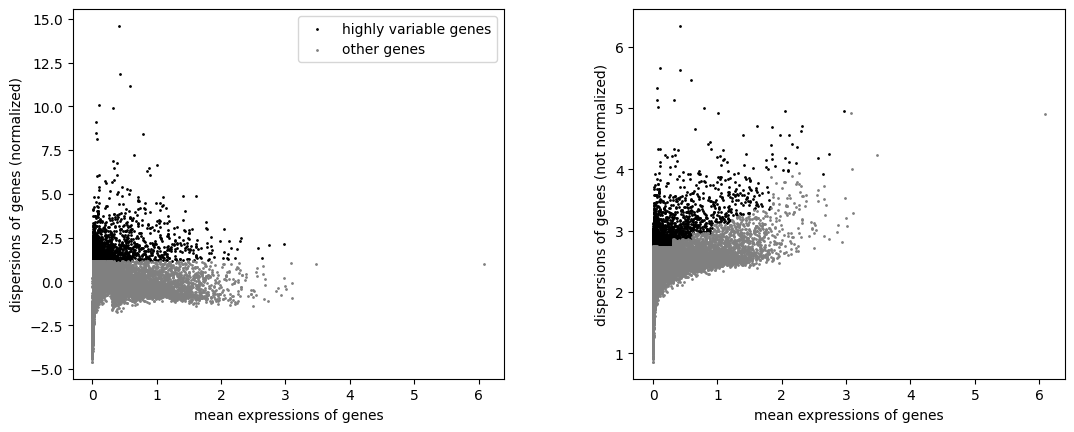

In [80]:
sc.pl.highly_variable_genes(adata)

In [81]:
adata = adata [:, adata.var.highly_variable]

In [82]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])

/tmp/ipykernel_174/2141330248.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt', 'pct_counts_ribo'])
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:657: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:657: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff


In [83]:
sc.pp.scale(adata, max_value=10)

In [84]:
sc.tl.pca(adata, svd_solver='arpack')

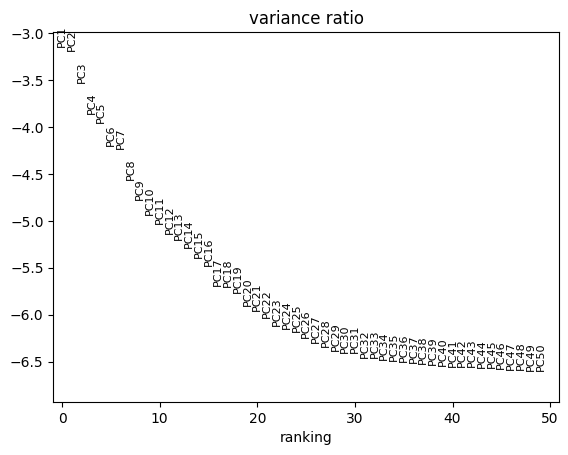

In [85]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [86]:
sc.pp.neighbors(adata, n_pcs=30)

In [88]:
adata.obsp['connectivities'].toarray()

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [89]:
adata.obsp['distances'].toarray()

array([[0.        , 0.        , 4.00853014, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [4.00853014, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [90]:
sc.tl.umap(adata)

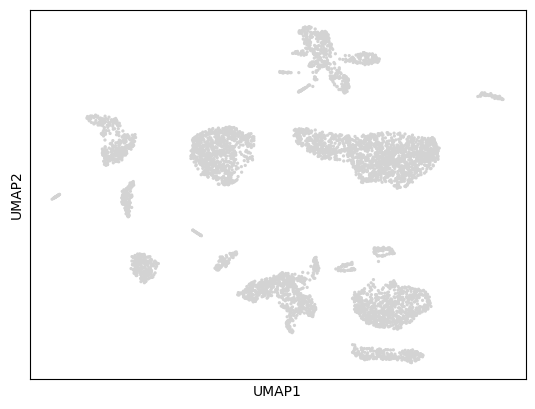

In [91]:
sc.pl.umap(adata)

In [94]:
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 126.6 MB/s eta 0:00:00


In [95]:
sc.tl.leiden(adata, resolution=0.5)

/tmp/ipykernel_174/1771924308.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [96]:
adata.obs

,doublet,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes,leiden
ATACTTCCAAGGTCTT-1_1,False,2122,5252.0,1.0,0.019040,4.0,0.076161,2120,2
AGACACTTCATACAGC-1_1,False,2223,4943.0,2.0,0.040461,0.0,0.000000,2222,1
TCATGCCGTCTTTCAT-1_1,False,2234,4993.0,0.0,0.000000,3.0,0.060084,2228,2
GATAGCTCAGGCTTGC-1_1,False,2167,4879.0,0.0,0.000000,0.0,0.000000,2165,2
TACATTCGTACGTACT-1_1,False,2253,4776.0,13.0,0.272194,1.0,0.020938,2248,7
...,...,...,...,...,...,...,...,...,...
CGCCATTGTTTGCCGG-1_1,False,355,410.0,3.0,0.731707,0.0,0.000000,355,7
CACTGGGGTCTACGTA-1_1,False,346,403.0,0.0,0.000000,0.0,0.000000,346,1
CATACTTGTAGAGGAA-1_1,False,360,410.0,2.0,0.487805,0.0,0.000000,360,0
TTTGGTTTCCACGGAC-1_1,False,299,405.0,0.0,0.000000,2.0,0.493827,299,10


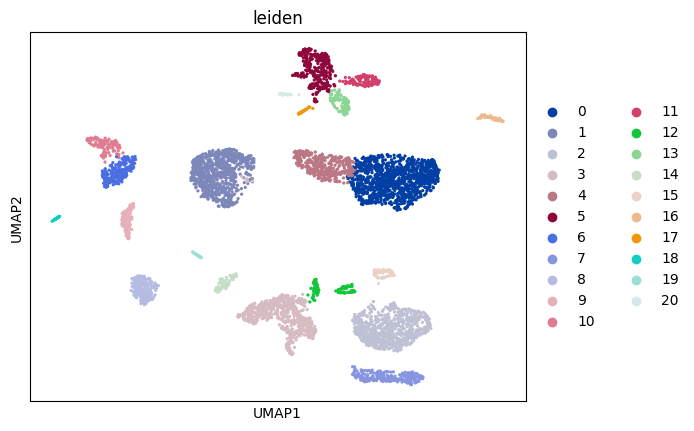

In [97]:
sc.pl.umap(adata, color=['leiden'])